# 二叉树

[返回总目录](README.md) · [打开进度表](LeetCode%20Hot100与高频题目刷题清单与进度追踪表.xlsx)

主分类采用 [LeetCode Hot100 官网](https://leetcode.cn/studyplan/top-100-liked/)。扩展题紧邻相关题；解法标签可与主分类不同。原笔记中的局部编号保留，以本目录中的 LeetCode 题号为准。

## 本文目录

- [94. 二叉树的中序遍历](#lc-94) — Hot100；已有详细笔记
- [104. 二叉树的最大深度](#lc-104) — Hot100；已有详细笔记
- [226. 翻转二叉树](#lc-226) — Hot100；已有详细笔记
- [101. 对称二叉树](#lc-101) — Hot100；已有详细笔记
- [543. 二叉树的直径](#lc-543) — Hot100；已有详细笔记
- [1617. 统计子树中城市之间的最大距离](#lc-1617) — 扩展题；已有详细笔记
- [2246. 相邻字符不同的最长路径](#lc-2246) — 扩展题；已有详细笔记
- [2538. 最大价值和与最小价值和的差值](#lc-2538) — 扩展题；已有详细笔记
- [102. 二叉树的层序遍历](#lc-102) — Hot100；已有详细笔记
- [98. 验证二叉搜索树](#lc-98) — Hot100；已有详细笔记
- [114. 二叉树展开为链表](#lc-114) — Hot100；已有详细笔记
- [105. 从前序与中序遍历序列构造二叉树](#lc-105) — Hot100；已有详细笔记
- [437. 路径总和 III](#lc-437) — Hot100；已有详细笔记
- [236. 二叉树的最近公共祖先](#lc-236) — Hot100；已有详细笔记
- [235. 二叉搜索树的最近公共祖先](#lc-235) — 扩展题；已有详细笔记
- [124. 二叉树中的最大路径和](#lc-124) — Hot100；已有详细笔记
- [337. 打家劫舍 III](#lc-337) — 扩展题；已有详细笔记
- [968. 监控二叉树](#lc-968) — 扩展题；已有详细笔记


## 基础与模板


对于具有if，else分支的递归结构而言，每一个分支都要有对应的return语句，一般来说在节点不为空的情况下return为节点自身。


## lc-94

**94. 二叉树的中序遍历**

二叉树 / 遍历 · Hot100 · 简单

[官网题目](https://leetcode.cn/problems/binary-tree-inorder-traversal/) · [返回本文目录](#本文目录) · [总目录](README.md)

笔记情况：已有详细笔记。解法标签：Morris遍历 / 前序后序扩展。

表格摘要：中序遍历的迭代实现以及前序后序遍历的迭代方法,对于中序方法来说,因为在需要在拆桥(根节点有左子树遍历完)和没有左子树的时候添加,因此可以不使用else,但是对于前序和后序遍历来说,在拆桥的时候不能再次添加,因此需要使用else.


**#1.中序遍历的迭代做法**

核心思想:在中序遍历当中,根节点的左子树的最右边节点是根节点的前驱节点

中序遍历时,当在“拆桥”或者“无左子树”时才记录节点

In [ ]:
# Definition for a binary tree node.
# class TreeNode:
#     def __init__(self, val=0, left=None, right=None):
#         self.val = val
#         self.left = left
#         self.right = right
class Solution:
    def inorderTraversal(self, root: Optional[TreeNode]) -> List[int]:
        res = []
        while root:
            if root.left:
                pre = root.left

                while pre.right and pre.right is not root:
                    pre = pre.right
                
                if pre.right is None:
                    pre.right = root
                    root = root.left
                    continue
                
                pre.right = None#能走到这一步说明左子树已经遍历完成.

            res.append(root.val)#没有左结点的情况下直接记录
            root = root.right

        return res

In [ ]:
#拓展:前序以及后序遍历的迭代方法

class Solution:

    def preorderTraversal(self, root: Optional[TreeNode]) -> List[int]:
        res = []
        while root:
            if root.left:
                pre = root.left
                while pre.right and pre.right is not root:
                    pre = pre.right

                # === 1. 未连则搭桥 ===
                if pre.right is None:
                    res.append(root.val)  # 【改动点 1】：搭桥时就记录！(根)
                    pre.right = root
                    root = root.left
                    continue

                # === 2. 已连则拆桥 ===
                pre.right = None
                # 【改动点 2】：拆桥时不再记录，直接往右走
                root = root.right

            else:
                # === 3. 无左子树 ===
                res.append(root.val)  # 没有左子树，也直接记录(根)
                root = root.right

        return res

    #后序遍历,技巧:将前序遍历的根->左->右改为根->右->左,最后再翻转结果列表即可
    class Solution:

    def postorderTraversal(self, root: Optional[TreeNode]) -> List[int]:
        res = []
        while root:
            # 原来的 left 全部变成 right
            if root.right:
                pre = root.right
                # 原来的 right 全部变成 left
                while pre.left and pre.left is not root:
                    pre = pre.left

                # 未连则搭桥
                if pre.left is None:
                    res.append(root.val)  # 搭桥时记录
                    pre.left = root
                    root = root.right  # 往右走
                    continue

                # 已连则拆桥
                pre.left = None
                root = root.left  # 往左走

            else:
                res.append(root.val)
                root = root.left

        # 【核心】：翻转结果列表 (根->右->左 变为 左->右->根)
        return res[::-1]

## lc-104

**104. 二叉树的最大深度**

二叉树 / 深度与结构 · Hot100 · 简单

[官网题目](https://leetcode.cn/problems/maximum-depth-of-binary-tree/) · [返回本文目录](#本文目录) · [总目录](README.md)

笔记情况：已有详细笔记。解法标签：树 / 深度优先搜索 / 广度优先搜索 / 二叉树。

表格摘要：递归：max(左子树深度, 右子树深度)+1；空节点返回0


**#3.检查树的深度**

In [ ]:
class Solution(object):
    def maxDepth(self, root):
        """
        :type root: Optional[TreeNode]
        :rtype: int
        """
        if root:#采用递归的方法求最大深度
            left = self.maxDepth(root.left)
            right = self.maxDepth(root.right)
            return 1 + max(left, right)
        else:
            return 0

## lc-226

**226. 翻转二叉树**

二叉树 / 深度与结构 · Hot100 · 简单

[官网题目](https://leetcode.cn/problems/invert-binary-tree/) · [返回本文目录](#本文目录) · [总目录](README.md)

笔记情况：已有详细笔记。解法标签：树 / 深度优先搜索 / 广度优先搜索 / 二叉树。

表格摘要：递归交换左右孩子；或层序遍历逐层交换


#4.树的翻转

In [ ]:
class Solution(object):
    def invertTree(self, root):
        """
        :type root: Optional[TreeNode]
        :rtype: Optional[TreeNode]
        """
        if not root:
            return None
        else:
            root.left = self.invertTree(root.right)
            root.right = self.invertTree(root.left)
            return root

## lc-101

**101. 对称二叉树**

二叉树 / 深度与结构 · Hot100 · 简单

[官网题目](https://leetcode.cn/problems/symmetric-tree/) · [返回本文目录](#本文目录) · [总目录](README.md)

笔记情况：已有详细笔记。解法标签：树 / 深度优先搜索 / 广度优先搜索 / 二叉树。

表格摘要：递归：两棵子树镜像对称（左.左==右.右 且 左.右==右.左）;注意需要判断根节点是否为空


### 💡 1. 检查树是否对称

> **解题思路**：核心在于处理以下 4 种边界与递归条件：

- 1️⃣ **两侧皆空**：无左节点也无右节点 $\rightarrow$ 返回 `True`
- 2️⃣ **单侧缺失**：只有左或只有右节点 $\rightarrow$ 返回 `False`
- 3️⃣ **数值冲突**：节点皆存在但 **值不相等** $\rightarrow$ 返回 `False`
- 4️⃣ **正常递推**：节点皆存在且 **值相等** $\rightarrow$ 继续向下递归

In [ ]:
# Definition for a binary tree node.
# class TreeNode(object):
#     def __init__(self, val=0, left=None, right=None):
#         self.val = val
#         self.left = left
#         self.right = right
class Solution(object):
    def isSymmetric(self, root):
        """
        :type root: Optional[TreeNode]
        :rtype: bool
        """
        if not root:
            return True

        def dfs(left,right):
            if not (left or right):#左树右树都不存在返回true
                return True
            if not (left and right):#左树右树只存在一个返回false
                return False
            if left.val!=right.val:#左右子树都存在但不对称返回false
                return False
            return dfs(left.left,right.right) and dfs(left.right,right.left)
        return dfs(root.left,root.right)

## lc-543

**543. 二叉树的直径**

二叉树 / 树的直径（一般树扩展） · Hot100 · 简单

[官网题目](https://leetcode.cn/problems/diameter-of-binary-tree/) · [返回本文目录](#本文目录) · [总目录](README.md)

笔记情况：已有详细笔记。解法标签：树 / 深度优先搜索 / 二叉树。

表格摘要：递归求每个节点左右子树深度，全局max(左深+右深)；直径不一定要过根


**#2.求树的最大直径**

In [1]:
class Solution(object):
    def diameterOfBinaryTree(self, root):
        self.diameter = 0

        def depth(node):
            if not node:
                return 0

            left = depth(node.left)      # 左子树高度,也是左子树的到根节点的最长路径
            right = depth(node.right)    # 右子树高度，也是右子树的到根节点的最长路径

            # 更新直径：左高度 + 右高度
            self.diameter = max(self.diameter, left + right)

            # 返回当前子树高度，返回值可以理解为当前树的高度，左子树与右子树高度可以理解为到根节点的高度
            return 1 + max(left, right)

        depth(root)
        return self.diameter

## lc-1617

**1617. 统计子树中城市之间的最大距离**

二叉树 / 树的直径（一般树扩展） · 扩展题 · 困难

[官网题目](https://leetcode.cn/problems/count-subtrees-with-max-distance-between-cities/) · [返回本文目录](#本文目录) · [总目录](README.md)

笔记情况：已有详细笔记。解法标签：树形DP / 一般树 / 直径。

相关 Hot100 题：[543. 二叉树的直径](08_二叉树.ipynb#lc-543)。

归类说明：枚举子树并统计直径，保留全部三种解法。

表格摘要：思想：利用枚举子集的思想以及求树的直径的思路，首先创建一个inset数组来对每个节点进行选与不选的操作，当i==n的时候，对前n个节点我们都已经做出了选择，接下来就是判断由这些节点构成的inset是否是一个子集，以及是子…


**_#20.统计子树中城市之间的最大距离_**

思想：利用枚举子集的思想以及求树的直径的思路，首先创建一个in_set数组来对每个节点进行选与不选的操作，当i==n的时候，对前n个节点我们都已经做出了选择，接下来就是判断由这些节点构成的in_set是否是一个子集，以及是子集的话直径是多少，构建vis数组来记录遍历过的节点，对于此题而言，无向且联通，因此对于in_set数组中任意一个为True的节点而言，以这个节点开始遍历的话能遍历到所有与它相连接的节点并得到该子树的直径，而当vis！= in_set的时候，证明当前是一片森林而非子树，不连通，因此它的值是不会被记录的。因此需要使用break语句来提前结束for循环。

In [ ]:
class Solution:
    def countSubgraphsForEachDiameter(self, n: int, edges):
        g = [[] for _ in range(n)]
        for x,y in edges:
            g[x-1].append(y-1)
            g[y-1].append(x-1)
        in_set = [False] * n
        res = [0] * (n-1)
        def f(i):
            if i == n:
                diameter = 0
                vis = [False] * n
                for i,y in enumerate(in_set):
                    if not y:continue

                    def dfs(x):
                        nonlocal diameter
                        max_len = 0
                        vis[x] = True
                        for y in g[x]:
                            if not vis[y] and in_set[y]:#对于已经遍历过的节点y而言，在计算以它为根节点的直径的时候肯定已经考虑了包含以x为根节点的最长路径的情况，因此不需要在遍历已经遍历过的节点？
                                curr_len = dfs(y) + 1
                                diameter = max(diameter,curr_len + max_len)
                                max_len = max(max_len,curr_len)
                        return max_len

                    dfs(i)
                    break

                if diameter and vis == in_set:
                    res[diameter-1] += 1
                return

            f(i+1)
            in_set[i] = True
            f(i+1)
            in_set[i] = False
        f(0)
        return res

做法二：利用位运算

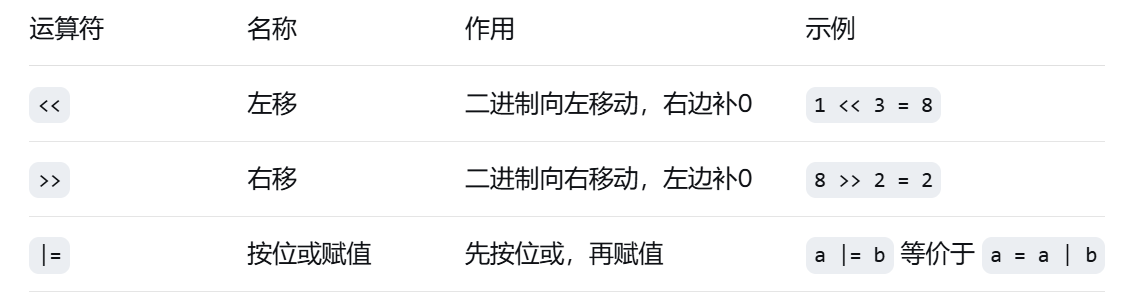

In [ ]:
class Solution:
    def countSubgraphsForEachDiameter(self, n: int, edges):
        # 建树
        g = [[] for _ in range(n)]
        for x, y in edges:
            g[x - 1].append(y - 1)
            g[y - 1].append(x - 1)  # 编号改为从 0 开始

        ans = [0] * (n - 1)
        #  二进制枚举，用二进制数来表示节点的选与不选，二进制从低到高第 i 位为 1 表示 i 在集合中，为 0 表示 i 不在集合中，例如集合 {0,2,3} 对应的二进制数为 1101
        for mask in range(3, 1 << n):# 需要至少两个点，所以从011（3）开始
            if (mask & (mask - 1)) == 0:  #用于判断mask中是否只有一位为1，==的优先级比&高，因此要有括号。
                continue
            # 求树的直径
            vis = diameter = 0
            def dfs(x: int) -> int:#传入的是城市在g数组中的序号，因此对于第i个城市而言，它的序号是i-1,对应的位置是i。
                nonlocal vis, diameter
                vis |= 1 << x  #将第x位标记为1，也就是记录遍历到的第x+1个节点
                max_len = 0
                for y in g[x]:
                    if (vis >> y & 1) == 0 and mask >> y & 1:  # y 没有访问过且在 mask 中，(x >> n) & 1 得到的是原始数字的第n位。
                        ml = dfs(y) + 1
                        diameter = max(diameter, max_len + ml)
                        max_len = max(max_len, ml)
                return max_len
            dfs(mask.bit_length() - 1)  # 从一个在 mask 中的点开始递归，返回最高位1的位置，这个点肯定被选中了。
            #bit_length()返回一个二进制数至少需要几位来表示，返回的值可以理解为最高位上1的位置，在减去1就代表着被选中的节点
            if vis == mask:
                ans[diameter - 1] += 1
        return ans

做法三：枚举直径端点+乘法原理
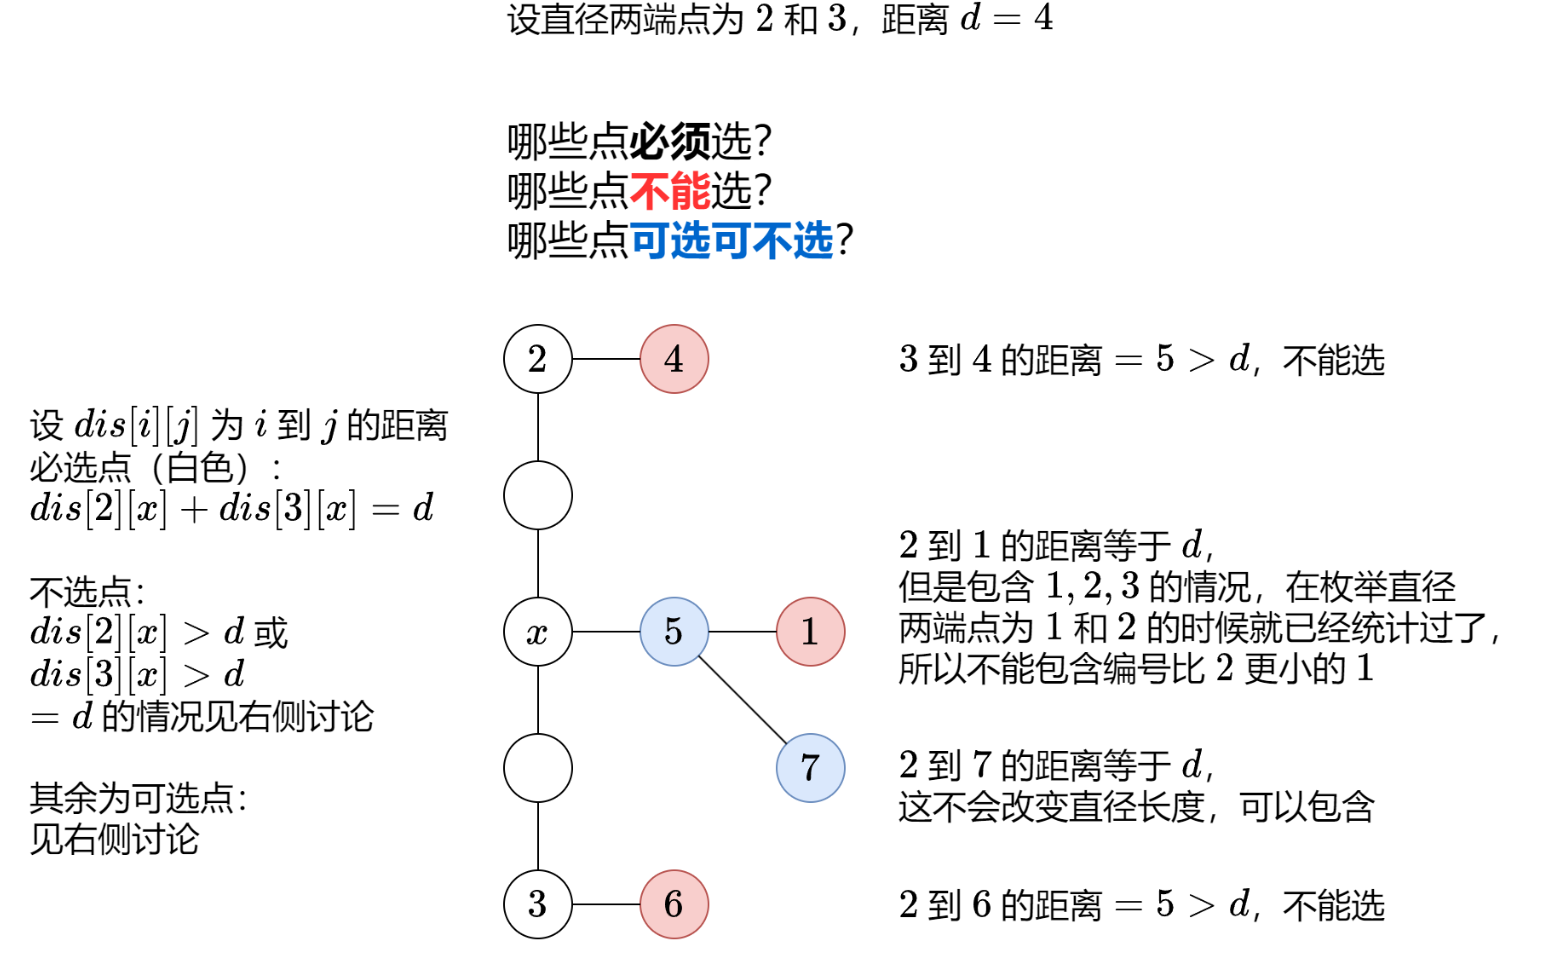

In [ ]:
class Solution:
    def countSubgraphsForEachDiameter(self, n: int, edges):
        # 建树
        g = [[] for _ in range(n)]
        for x, y in edges:
            g[x - 1].append(y - 1)
            g[y - 1].append(x - 1)  # 编号改为从 0 开始

        # 计算树上任意两点的距离
        dis = [[0] * n for _ in range(n)]
        def dfs(x: int, fa: int) -> None:
            for y in g[x]:
                if y != fa:
                    dis[i][y] = dis[i][x] + 1  # 自顶向下
                    dfs(y, x)
        for i in range(n):
            dfs(i, -1)  # 计算 i 到其余点的距离，最开始的时候计算的是i到它的子节点的距离，进一步递归计算的就是i到子节点的子节点的距离，以此类推求出从i出发到达某个点的距离。

        def dfs2(x: int, fa: int) -> int:
            # 能递归到这，说明 x 可以选
            cnt = 1  # 选 x
            for y in g[x]:#判断x的子节点构成的子树的选择问题，因为这些子树的选与不选是互相独立的，所以利用乘法原理
                if y != fa and \
                   (di[y] < d or di[y] == d and y > j) and \
                   (dj[y] < d or dj[y] == d and y > i):  # 满足这些条件就可以选
                    cnt *= dfs2(y, x)  # 每棵子树互相独立，采用乘法原理
            if di[x] + dj[x] > d:  # x 是可选点而非必选点，也就是说点没有在直径的路径上
                cnt += 1  # 不选 x
            return cnt
        ans = [0] * (n - 1)
        for i, di in enumerate(dis):
            for j in range(i + 1, n):
                dj = dis[j]
                d = di[j]
                ans[d - 1] += dfs2(i, -1)
        return ans

## lc-2246

**2246. 相邻字符不同的最长路径**

二叉树 / 树的直径（一般树扩展） · 扩展题 · 困难

[官网题目](https://leetcode.cn/problems/longest-path-with-different-adjacent-characters/) · [返回本文目录](#本文目录) · [总目录](README.md)

笔记情况：已有详细笔记。解法标签：树形DP / 一般树 / 直径。

相关 Hot100 题：[543. 二叉树的直径](08_二叉树.ipynb#lc-543) · [124. 二叉树中的最大路径和](08_二叉树.ipynb#lc-124)。

归类说明：带相邻字符约束的一般树最长路径，扩展二叉树直径。

表格摘要：树形DP：求经过每个节点的最长路径，仅相邻字符不同才可连边；维护第一大/第二大分支


**_树形dp：_**

_**树形dp的方法保证了在无向图中，无论从哪个节点开始递归，都能返回最长直径**_

**_#18.相邻字符不同的最长路径_**
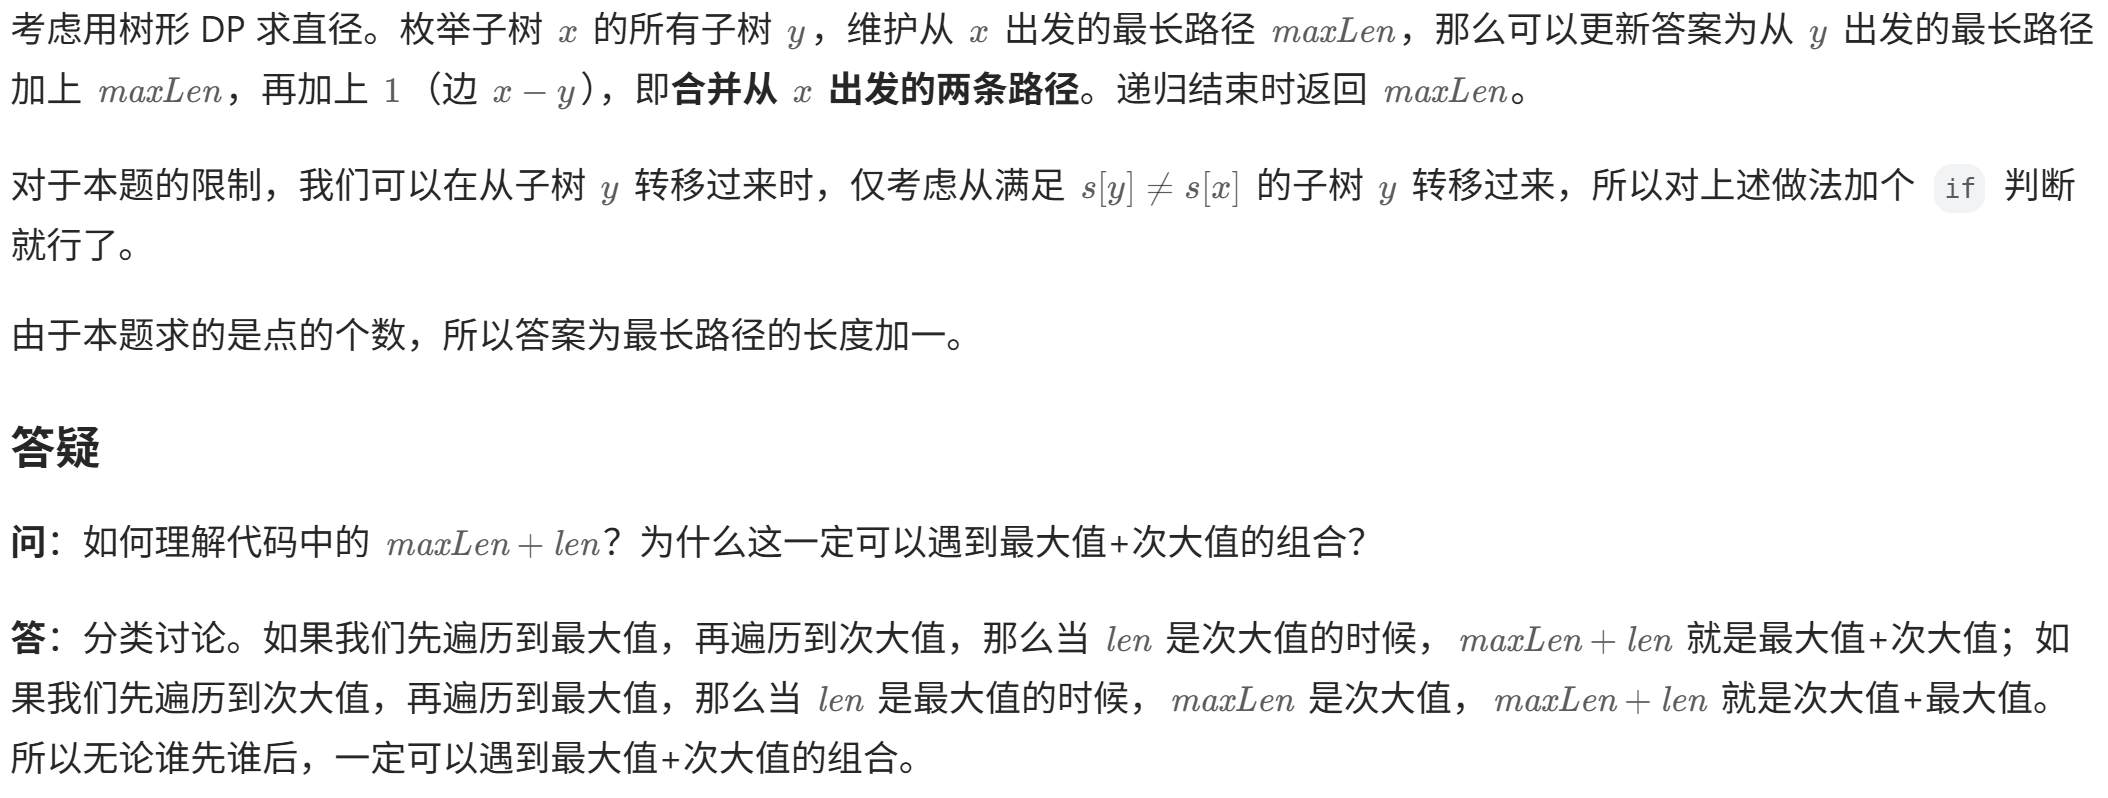

In [ ]:
class Solution:
    def longestPath(self, parent, s: str) -> int:
        n = len(parent)
        f = [[] for _ in range(n)]
        for i in range(1,n):
            f[parent[i]].append(i)
        res = 0
        def dfs(i):#当处理的是无向图的问题时，在dfs中加入fa表示父节点，并在遍历子节点的时候加入y!=fa的判断即可
            nonlocal res
            x_len = 0#以i这个节点为根节点某一条分支的边的数目
            for y in f[i]:
                y_len = dfs(y) + 1#dfs要在判断外面，因为如果在里面的话当条件不成立的时候res不能进行更新
                if s[y] != s[i]:
                    res = max(res,x_len + y_len)
                    x_len = max(x_len,y_len)
            return x_len#返回的是当这个节点作为叶子结点时的最大路径

        dfs(0)
        return res + 1#最后加1来表示求解的是边数

## lc-2538

**2538. 最大价值和与最小价值和的差值**

二叉树 / 树的直径（一般树扩展） · 扩展题 · 困难

[官网题目](https://leetcode.cn/problems/difference-between-maximum-and-minimum-price-sum/) · [返回本文目录](#本文目录) · [总目录](README.md)

笔记情况：已有详细笔记。解法标签：树形DP / 一般树 / 直径。

相关 Hot100 题：[543. 二叉树的直径](08_二叉树.ipynb#lc-543) · [124. 二叉树中的最大路径和](08_二叉树.ipynb#lc-124)。

归类说明：一般树带点权路径问题，使用树形DP。

表格摘要：树形DP：维护每个节点向下的路径价值最大和与最小和；答案为max-min，可在节点处拼接两条路径


**_#19.最大价值和与最小价值和的差值：_**

In [ ]:
class Solution:
    def maxOutput(self, n: int, edges, price) -> int:
        g = [[] for _ in range(n)]
        for x, y in edges:
            g[x].append(y)
            g[y].append(x)  # 建树

        ans = 0
        def dfs(x: int, fa: int):#计算的是以x节点为拐点的路径的最大价值，这条路径需要减去其中一个叶子节点
            nonlocal ans
            max_s1 = p = price[x]
            max_s2 = 0#max_s1,max_s2的作用与max_len一致，用于记录遍历到的以当前节点x为根节点的包含叶子节点与不包含的当前最大值，当根节点不是叶子结点的时候，二者都包含price[x]的值。
            for y in g[x]:
                if y == fa: continue#对于没有环的无向图而言，如果y!= fa那么这个节点就没有被遍历过
                s1, s2 = dfs(y, x)#s1,s2中不包含节点x的值，但包含y的值(在y不是叶子节点的情况下)
                # 前面最大带叶子的路径和(包含根节点)+ 当前不带叶子的路径和(不包含根节点)
                # 前面最大不带叶子的路径和 + 当前带叶子的路径和
                ans = max(ans, max_s1 + s2, max_s2 + s1)
                max_s1 = max(max_s1, s1 + p)
                max_s2 = max(max_s2, s2 + p)  # 这里加上 p 是因为 x 必然不是叶子
            return max_s1, max_s2
        dfs(0, -1)
        return ans

## lc-102

**102. 二叉树的层序遍历**

二叉树 / 遍历 · Hot100 · 中等

[官网题目](https://leetcode.cn/problems/binary-tree-level-order-traversal/) · [返回本文目录](#本文目录) · [总目录](README.md)

笔记情况：已有详细笔记。解法标签：树 / 广度优先搜索 / 二叉树。

表格摘要：树的层序遍历：树的层序遍历不需要提前知道树的深度 注意：使用 res = [[]nums] 并不能生成一个含有nums个列表的二维列表，应该使用: res = [[] for in range(nums)]


**#5.树的层序遍历：树的层序遍历不需要提前知道树的深度**

注意：使用

            res = [[]*nums]
并不能生成一个含有nums个列表的二维列表，应该使用:

            res = [[] for _ in range(nums)]

In [ ]:
class Solution(object):#在生成含有列表的列表时，可以先生成小列表，然后将小列表加入到大列表中
    def levelOrder(self, root):
        if not root:
            return []
        else:
            queue = [root]
            res = []
            while queue:
                length = len(queue)
                current_list = [] # 每次循环创建新的列表对象
                for i in range(length):#对某一层的元素进行处理
                    node = queue.pop(0)
                    current_list.append(node.val)
                    if node.left:
                        queue.append(node.left)
                    if node.right:
                        queue.append(node.right)#添加的是对新列表的引用
                res.append(current_list)
            return res

## lc-98

**98. 验证二叉搜索树**

二叉树 / 二叉搜索树 · Hot100 · 中等

[官网题目](https://leetcode.cn/problems/validate-binary-search-tree/) · [返回本文目录](#本文目录) · [总目录](README.md)

笔记情况：已有详细笔记。解法标签：树 / 深度优先搜索 / 二叉搜索树 / 二叉树。

表格摘要：中序遍历结果严格递增；或递归传递(lower, upper)上下界校验


**#7.验证二叉搜索树**

**对于一棵有效二叉搜索树而言，中序遍历的结果是严格递增的**



In [ ]:
# Definition for a binary tree node.
# class TreeNode:
#     def __init__(self, val=0, left=None, right=None):
#         self.val = val
#         self.left = left
#         self.right = right
class Solution:
    def isValidBST(self, root: Optional[TreeNode]) -> bool:
        def check(root,l,r):
            if not root:
                return True
            if not (l < root.val < r):
                return False
            return check(root.left,l,root.val) and check(root.right,root.val,r)
        return check(root,-float('inf'),float('inf'))

## lc-114

**114. 二叉树展开为链表**

二叉树 / 结构变换 · Hot100 · 中等

[官网题目](https://leetcode.cn/problems/flatten-binary-tree-to-linked-list/) · [返回本文目录](#本文目录) · [总目录](README.md)

笔记情况：已有详细笔记。解法标签：栈 / 树 / 深度优先搜索 / 链表 / 二叉树。

表格摘要：while 栈非空: 1. 弹出当前节点 = 栈.pop() 2. 连接操作：if pre: pre.right = 当前节点; pre.left = None 3. 入栈操作：先右后左（因为栈是后进先出）


**#8.将二叉树展开为列表**



In [ ]:
class Solution(object):
    def flatten(self, root):
        """
        :type root: Optional[TreeNode]
        :rtype: None Do not return anything, modify root in-place instead.
        """
        #此方法使用到栈的属性，先压右在压左保证先序遍历，使用的非递归先序遍历的方式还是很有意思的，这个要留意。
        if not root:
            return []
        else:
            stack = [root]
            prev = None
            while stack:
                node = stack.pop()#弹出的时候存在左节点会先弹左节点，
                if prev:#指的是当前节点的根节点
                    prev.right = node
                    prev.left = None
                prev = node
                if node.right:
                    stack.append(node.right)
                if node.left:
                    stack.append(node.left)
            return root

    while 栈非空:
        1. 弹出当前节点 = 栈.pop()
        2. 连接操作：if pre: pre.right = 当前节点; pre.left = None
        3. 入栈操作：先右后左（因为栈是后进先出）

## lc-105

**105. 从前序与中序遍历序列构造二叉树**

二叉树 / 构造二叉树 · Hot100 · 中等

[官网题目](https://leetcode.cn/problems/construct-binary-tree-from-preorder-and-inorder-traversal/) · [返回本文目录](#本文目录) · [总目录](README.md)

笔记情况：已有详细笔记。解法标签：树 / 数组 / 哈希表 / 分治 / 二叉树。

表格摘要：方法一： 这个方法从递归的角度入手，先获取先序遍历中根节点在中序遍历中的索引，然后根据索引确定根节点的左子树和右子树有多少节点，在递归调用构建左右子树 例如，对于这个例子而言，根节点3在中序中对应的位置为1，也就说明了左…


**#6.从前序与中序构建二叉树**

方法一：

In [ ]:
class TreeNode(object):
    def __init__(self, val=0, left=None, right=None):
        self.val = val
        self.left = left
        self.right = right

class Solution(object):#这个方法从递归的角度入手，先获取先序遍历中根节点在中序遍历中的索引，然后根据索引确定根节点的左子树和右子树有多少节点，在递归调用构建左右子树
    def buildTree(self, preorder, inorder):
        if not preorder:
            return None
        else:
            index = inorder.index(preorder[0])
            root = TreeNode(preorder[0])          #拓展：从中序与后序构建二叉树，只需更改先序的索引即可
            root.left = self.buildTree(preorder[1:index+1],inorder[0:index]) #(preorder[0:index],inorder[0:index])
            root.right = self.buildTree(preorder[index+1:],inorder[index+1:])#preorder[index:-1],inorder[index+1:])
            return root

这个方法从递归的角度入手，先获取先序遍历中根节点在中序遍历中的索引，然后根据索引确定根节点的左子树和右子树有多少节点，在递归调用构建左右子树

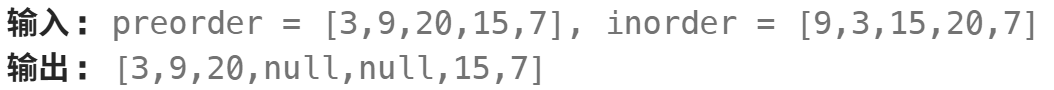

例如，对于这个例子而言，根节点3在中序中对应的位置为1，也就说明了左子树有一个节点，因此在后续的分配过程中，先序列表的值从第二个元素开始，将1个元素分给左子树，而对于中序遍历而言，只需将从第一个元素开始到根节点之前的元素返回即可。

方法二：

In [ ]:
class Solution(object):
    def buildTree(self, preorder, inorder):
        """
        :type preorder: List[int]
        :type inorder: List[int]
        :rtype: Optional[TreeNode]
        """
        def helper(root_index,left,right):#函数中的left与right反映的是左子树数组与右子树数组在中序列表中对应的索引，作用是用作递归的基本结束条件
            if left > right:              #root_index代表着根节点在先序列表中的索引
                return None
            else:
                root = TreeNode(preorder[root_index])
                i = inorder_dict[preorder[root_index]]#i代表着根节点在中序列表中的索引
                root.left = helper(root_index+1,left,i-1)
                root.right = helper(root_index+1+i-left,i+1,right)#i-left代表着一共有多少棵左子树，在第一棵左子树的位置移动左子树的距离，就到了右子树的根节点
                return root

        inorder_dict = {val:idx for idx,val in enumerate(inorder)}
        return helper(0,0,len(preorder)-1)

        利用前序与中序构建二叉树：
        root.left = helper(root_index+1,left,i-1)
        root.right = helper(root_index+1+i-left,i+1,right)
        右子树根节点位置=根节点位置+左子树个数+1

        利用后序与中序构建二叉树：
        root.left = helper(root_index - (right - i) - 1,left,i-1)
        root.right = helper(root_index - 1,i+1,right)
        左子树根节点位置 = 根节点位置 - 右子树个数 - 1

## lc-437

**437. 路径总和 III**

二叉树 / 前缀和路径 · Hot100 · 中等

[官网题目](https://leetcode.cn/problems/path-sum-iii/) · [返回本文目录](#本文目录) · [总目录](README.md)

笔记情况：已有详细笔记。解法标签：树 / 深度优先搜索 / 二叉树。

表格摘要：采用前缀和的思想，最后在单次函数执行完之前(也就意味着这个节点作为路径终点的所有路径遍历完成)，将字典当中从根节点到当前节点的数量-1，避免对其他分支造成影响。此题可以看作是560.和为k的子数组的升级版本;同时对于使用前缀和的题目来说,有两点需要注意:1.首先设置cnt[0]=1,避免漏算 2.先判断时候有cnt[curr_sum - target_sum]存在,在更新cnt.


**#11.路径总和III**

采用前缀和的思想，最后在单次函数执行完之前，将当前之和删除，避免对其他分支造成影响。

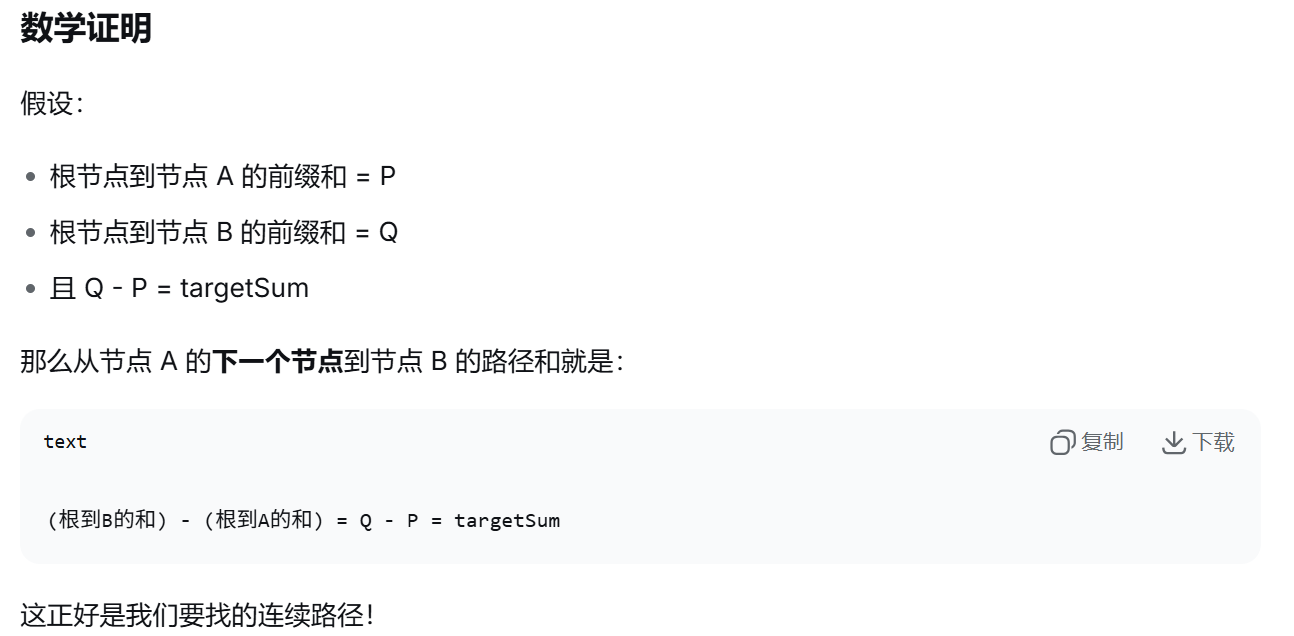
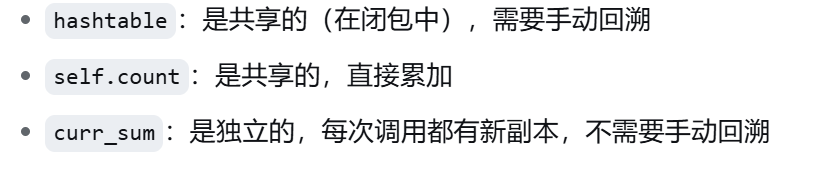

In [ ]:
class Solution:
    def pathSum(self, root: Optional[TreeNode], targetSum: int) -> int:
        # key：从根到 node 的节点值之和
        # value：节点值之和的出现次数
        # 注意在递归过程中，哈希表只保存根到 node 的路径的前缀的节点值之和
        cnt = defaultdict(int)  
        cnt[0] = 1 # 空路径的节点值之和为 0,存在从根节点开始就为 targetSum 的路径
        ans = 0

        # s 表示从根到 node 的父节点的节点值之和（node 的节点值尚未计入）
        def dfs(node: Optional[TreeNode], s: int) -> None:
            if node is None:
                return

            nonlocal ans
            s += node.val
            # 把 node 当作路径的终点，统计有多少个起点
            ans += cnt[s - targetSum] #先更新ans,在更新cnt,因为题目要求统计的是非空路径的个数,如果反过来,举一个最简单的例子,当target_sum=0的时候,如果根结点的值为1,
                                        #先更新cnt,那么cnt[1]=1,然后在执行ans += cnt[1-0],那么ans=1,但是实际上没有符合条件的路径,所以应该先更新ans,再更新cnt
            cnt[s] += 1
            dfs(node.left, s)
            dfs(node.right, s)
            cnt[s] -= 1  # 恢复现场（撤销 cnt[s] += 1）,因为此时遍历完了这个节点作为路径终点的所有路径,所以应该将这个节点的值从cnt中删除,以便于其他节点作为路径终点的时候不会受到这个节点的影响

        dfs(root, 0)
        return ans

## lc-236

**236. 二叉树的最近公共祖先**

二叉树 / 最近公共祖先 · Hot100 · 中等

[官网题目](https://leetcode.cn/problems/lowest-common-ancestor-of-a-binary-tree/) · [返回本文目录](#本文目录) · [总目录](README.md)

笔记情况：已有详细笔记。解法标签：树 / 深度优先搜索 / 二叉树。

表格摘要：递归：节点为p或q为空都返回自身；左右子树返回值均非空时当前节点即最近公共祖先;否则执行return left if left else right判断


**#9.二叉树的最近公共祖先**
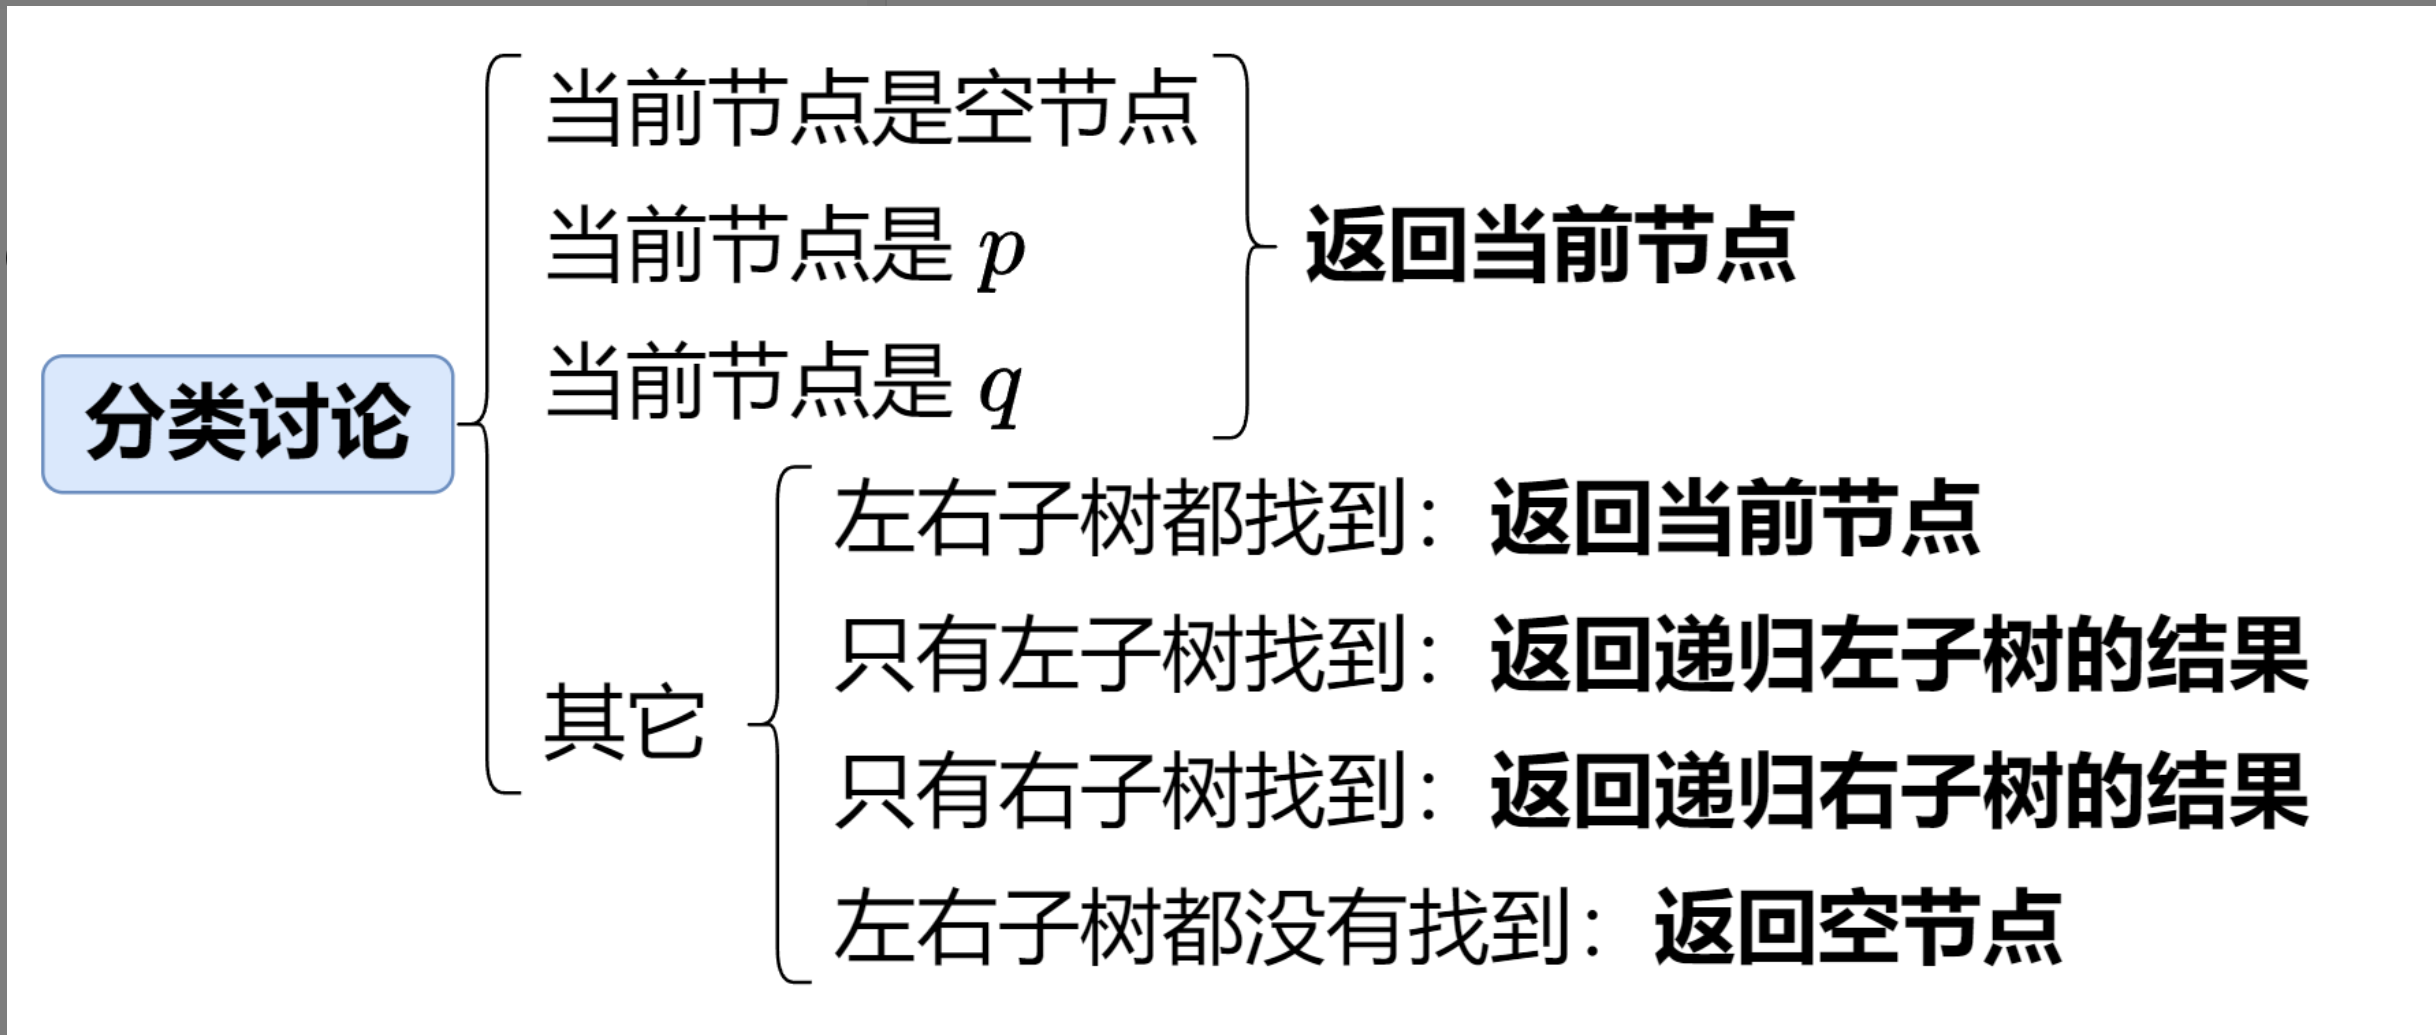

In [ ]:
class Solution(object):#该题的最大启发在于树中的递归值的返回，不需要修改树的结构，只需要返回左右子树是否包含节点的信息就可以了，如果有那就返回这个节点，如果没有不处理默认返回none。同时应该简化对节点的判断，将判断落在节点上，而非节点的左右节点。

    def lowestCommonAncestor(self, root: 'TreeNode', p: 'TreeNode', q: 'TreeNode') -> 'TreeNode':#从下往上判断,通过递归先走到最深处
        def dfs(node):
            if not node:
                return None
            if node == p or node ==q:#当前节点等于p或者q的时候，就没必要继续探索这个节点的左右子树了，因为如果遍历其他子树没有发现p或者q，说明p或者q位于这个节点的子树下面，此时公共祖先就是node
                return node

            left = dfs(node.left)
            right = dfs(node.right)

            if left and right:
                return node

            return left if left else right

        return dfs(root)

## lc-235

**235. 二叉搜索树的最近公共祖先**

二叉树 / 最近公共祖先 · 扩展题 · 中等

[官网题目](https://leetcode.cn/problems/lowest-common-ancestor-of-a-binary-search-tree/) · [返回本文目录](#本文目录) · [总目录](README.md)

笔记情况：已有详细笔记。解法标签：最近公共祖先。

相关 Hot100 题：[236. 二叉树的最近公共祖先](08_二叉树.ipynb#lc-236)。

归类说明：利用二叉搜索树的有序性质寻找最近公共祖先。

表格摘要：利用BST有序性：p、q都较小时向左，都较大时向右，否则当前节点为最近公共祖先。


**#10.二叉搜索树的最近公共祖先:**
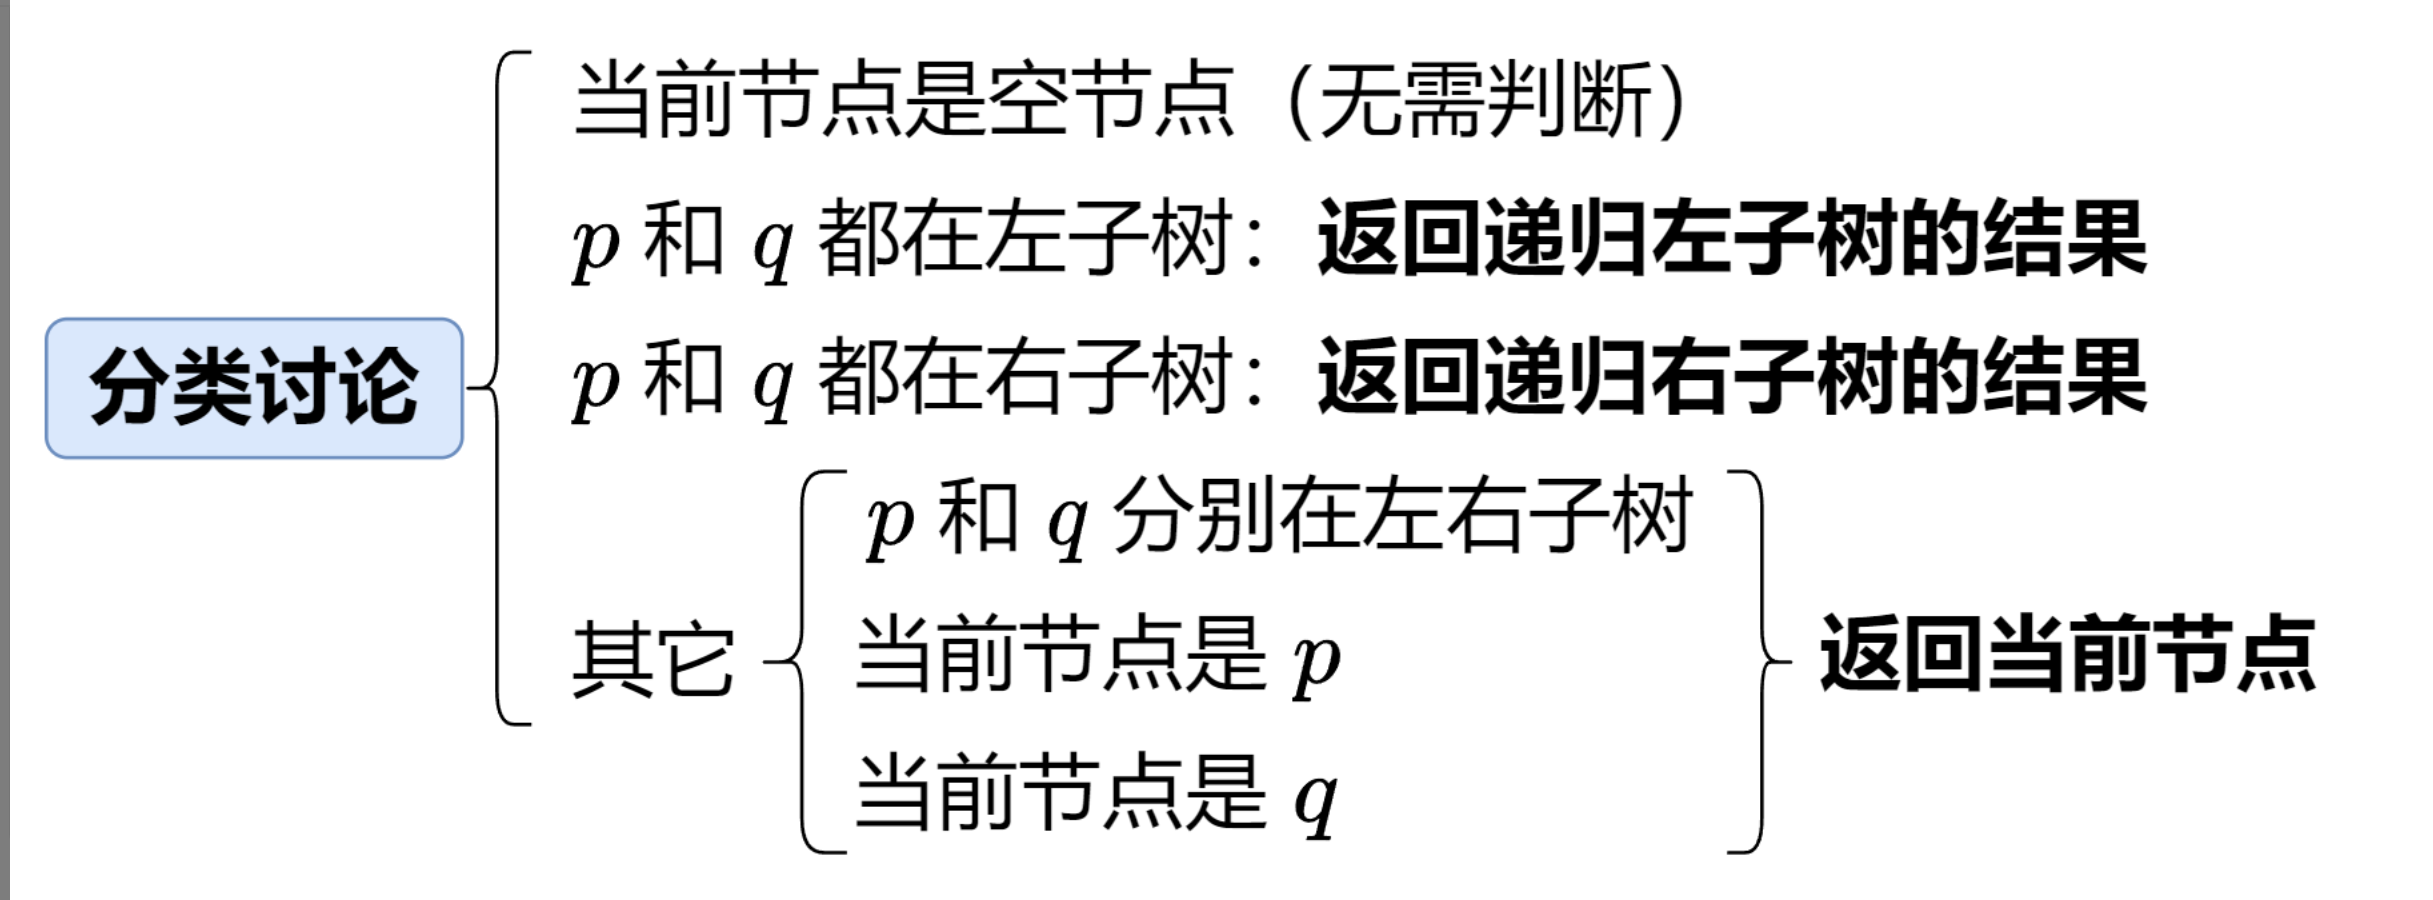
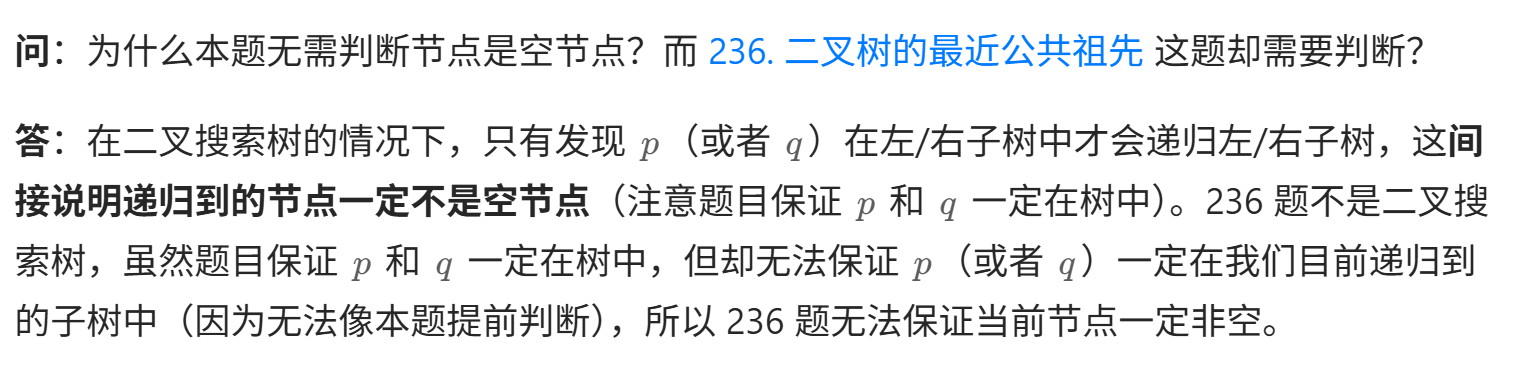

In [ ]:
class Solution:
    def lowestCommonAncestor(self, root: 'TreeNode', p: 'TreeNode', q: 'TreeNode') -> 'TreeNode':
        x = root.val
        if p.val < x and q.val < x:  # p 和 q 都在左子树
            return self.lowestCommonAncestor(root.left, p, q)
        if p.val > x and q.val > x:  # p 和 q 都在右子树
            return self.lowestCommonAncestor(root.right, p, q)
        return root  # 其它

## lc-124

**124. 二叉树中的最大路径和**

二叉树 / 树形DP · Hot100 · 困难

[官网题目](https://leetcode.cn/problems/binary-tree-maximum-path-sum/) · [返回本文目录](#本文目录) · [总目录](README.md)

笔记情况：已有详细笔记。解法标签：树 / 深度优先搜索 / 动态规划 / 二叉树。

表格摘要：递归返回单边最大路径和 node.val+max(左,右,0)；全局max记录经过当前节点的最大路径和


**#11.最大路径和**

这个题有用到求连续n个数的最大和以及求树的最大直径的思路，采用递归方法在返回值时应该注意，不能将node.val+left+right返回，因为后续node会作为其他节点的子节点，所以最多只能返回当前节点与一个子节点的和，这个思路与求树的最大直径相似，因此我们要创建一个全局数组用来存放历史最大值，并将历史最大值与现在的和进行比较，看看是否需要更改。

**递归返回单边最大路径和 node.val+max(左,右,0)；遍历每一个节点，并以该节点作为路径的‘拐点’，来计算并更新全局的最大路径和。**


In [ ]:
# Definition for a binary tree node.
# class TreeNode(object):
#     def __init__(self, val=0, left=None, right=None):
#         self.val = val
#         self.left = left
#         self.right = right
class Solution(object):
    def maxPathSum(self, root):
        """
        :type root: Optional[TreeNode]
        :rtype: int
        """
        self.max_num = float('-inf')
        def check(root):
            if not root:
                return 0
            else:
                left = max(check(root.left),0)#对left以及right的处理是本题的关键
                right = max(check(root.right),0)#
                curr_sum = root.val+left+right
                self.max_num = max(self.max_num,curr_sum)
                return max(left,right)+root.val#但当前节点必须报告它能贡献的真实值，因此即使当root.val是负的也要返回，但为负值的情况下这个节点的父亲节点不会将其加入到路径中去
        check(root)
        return self.max_num

## lc-337

**337. 打家劫舍 III**

二叉树 / 树形DP · 扩展题 · 中等

[官网题目](https://leetcode.cn/problems/house-robber-iii/) · [返回本文目录](#本文目录) · [总目录](README.md)

笔记情况：已有详细笔记。解法标签：树形DP / 状态机DP。

相关 Hot100 题：[198. 打家劫舍](15_动态规划.ipynb#lc-198) · [124. 二叉树中的最大路径和](08_二叉树.ipynb#lc-124)。

归类说明：把打家劫舍推广到树结构，同时在动态规划导航中交叉引用。

表格摘要：树形DP：每个节点返回[偷,不偷]；偷则子节点不能偷，不偷取子节点最大值；后序遍历


**_树上最大独立集_**

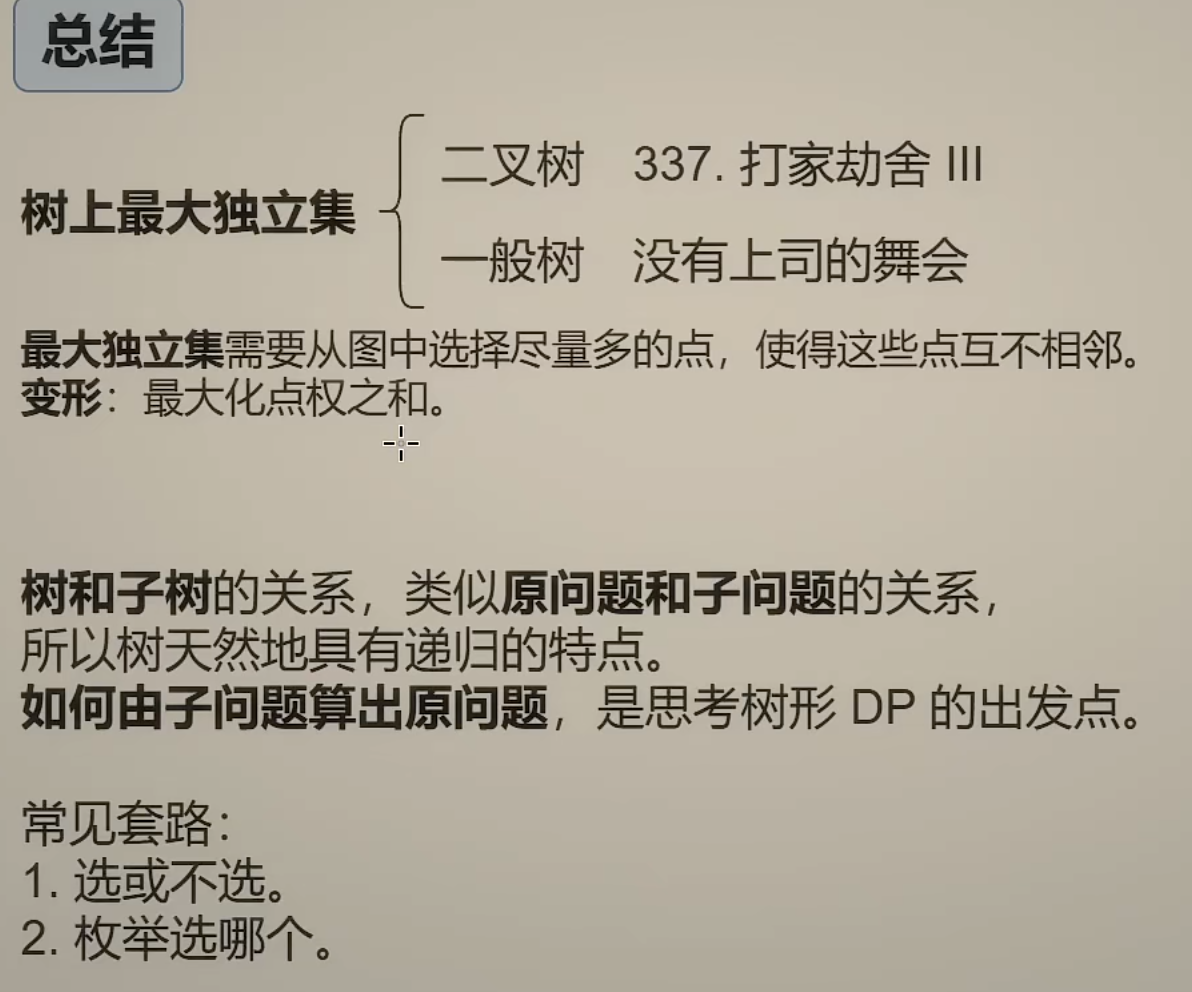

**_#21.打家劫舍III_**
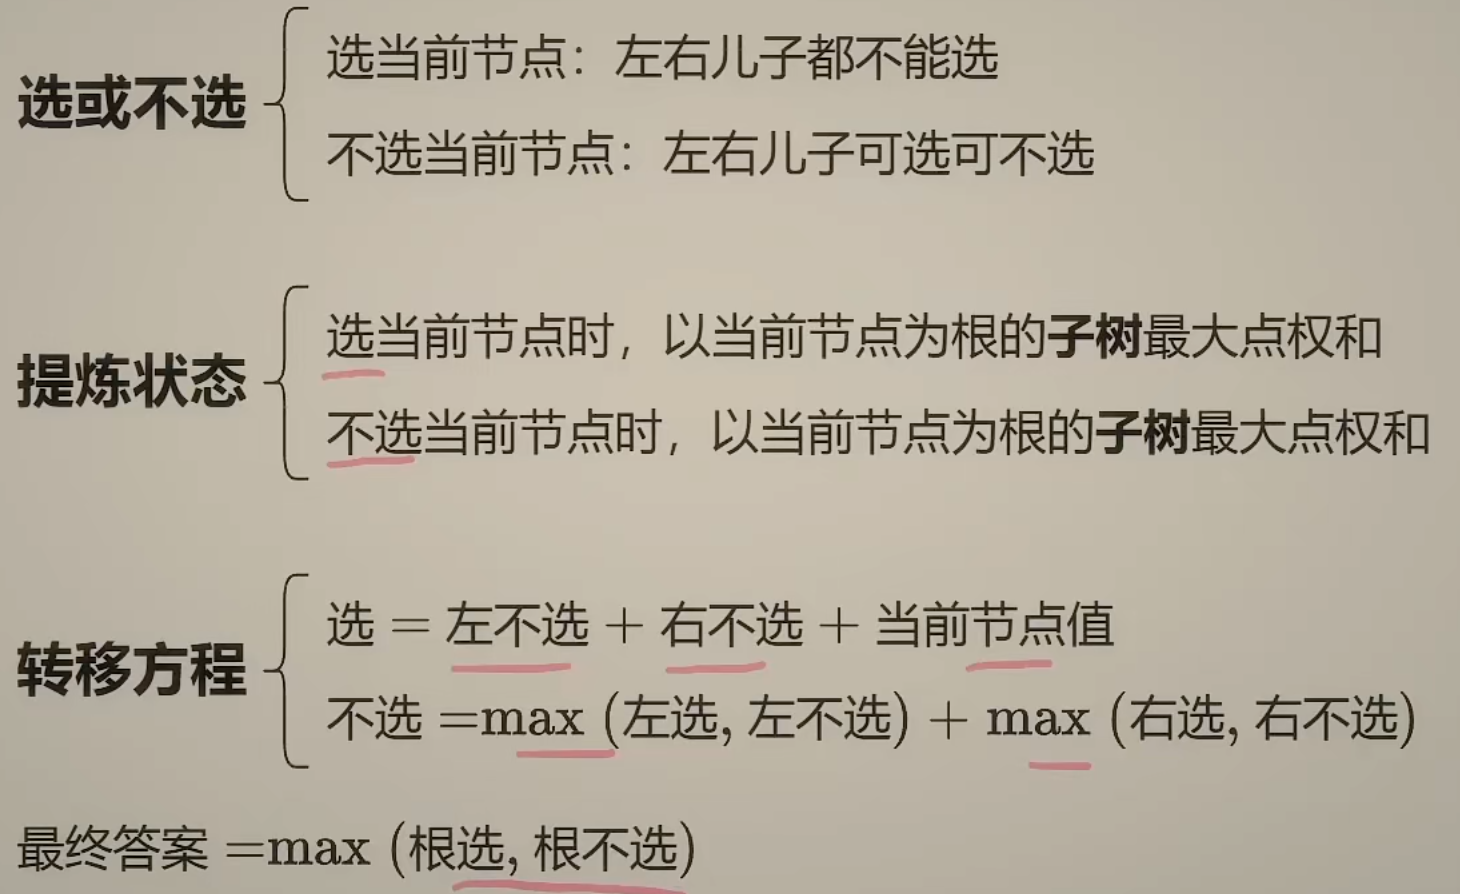

In [ ]:
#采用类似状态机的思路：对于每个节点而言，返回选这个节点的值与不选这个节点的值来表示两种状态。
class Solution:
    def rob(self, root) -> int:
        def dfs(node):
            if not node:
                return 0,0
            l_rob,l_not_rob = dfs(node.left)
            r_rob,r_not_rob = dfs(node.right)
            rob,not_rob = node.val + l_not_rob + r_not_rob,max(l_rob,l_not_rob) + max(r_rob,r_not_rob)
            return rob,not_rob
        return max(dfs(root))

In [ ]:
#一般树版本
class Solution:
    def rob(self, happy,relation,n) -> int:
        f = [[] for _ in range(n)]
        indegree = [0] * n
        for chi,par in relation:
            f[par-1].append(chi-1)
            indegree[chi-1] += 1#名为chi的节点存储在chi-1的索引下
        root = next(i for i in range(n) if indegree[i] == 0)#找到第一个入读为0的节点，也就是根节点。

        def dfs(i):
            if not f[i]:
                return 0,0
            sel,not_sel = 0,0
            for y in f[i]:#通过循环的方式遍历当前节点的子节点，并将子节点选与不选时的点权和进行累加
                y_sel,y_not_sel = dfs(y)
                sel += y_not_sel#当前这个节点要选，那么将这个节点的子节点不选情况下的点权和进行累加
                not_sel += max(y_sel,y_not_sel)#当前这个节点不选的时候，它的子节点可选可不选，记录这两种情况的最大值
            return sel+happy[i],not_sel
        return max(dfs(root))

## lc-968

**968. 监控二叉树**

二叉树 / 树形DP · 扩展题 · 困难

[官网题目](https://leetcode.cn/problems/binary-tree-cameras/) · [返回本文目录](#本文目录) · [总目录](README.md)

笔记情况：已有详细笔记。解法标签：树形DP / 一般树扩展。

相关 Hot100 题：[104. 二叉树的最大深度](08_二叉树.ipynb#lc-104) · [124. 二叉树中的最大路径和](08_二叉树.ipynb#lc-124)。

归类说明：以节点状态递推覆盖方案，是树形DP扩展。

表格摘要：此题的核心是针对每个节点，从节点的不同状态入手，分析节点在不同状态下的最小数目或者最小点权和。 分析一下红色节点的处理逻辑，对于红色节点而言，它必须有一个子节点是蓝色节点，而对于黄色节点而言，它的子节点是由红色与蓝色构成…


**_#22.监控二叉树_**

此题的核心是针对每个节点，从节点的不同状态入手，分析节点在不同状态下的最小数目或者最小点权和。
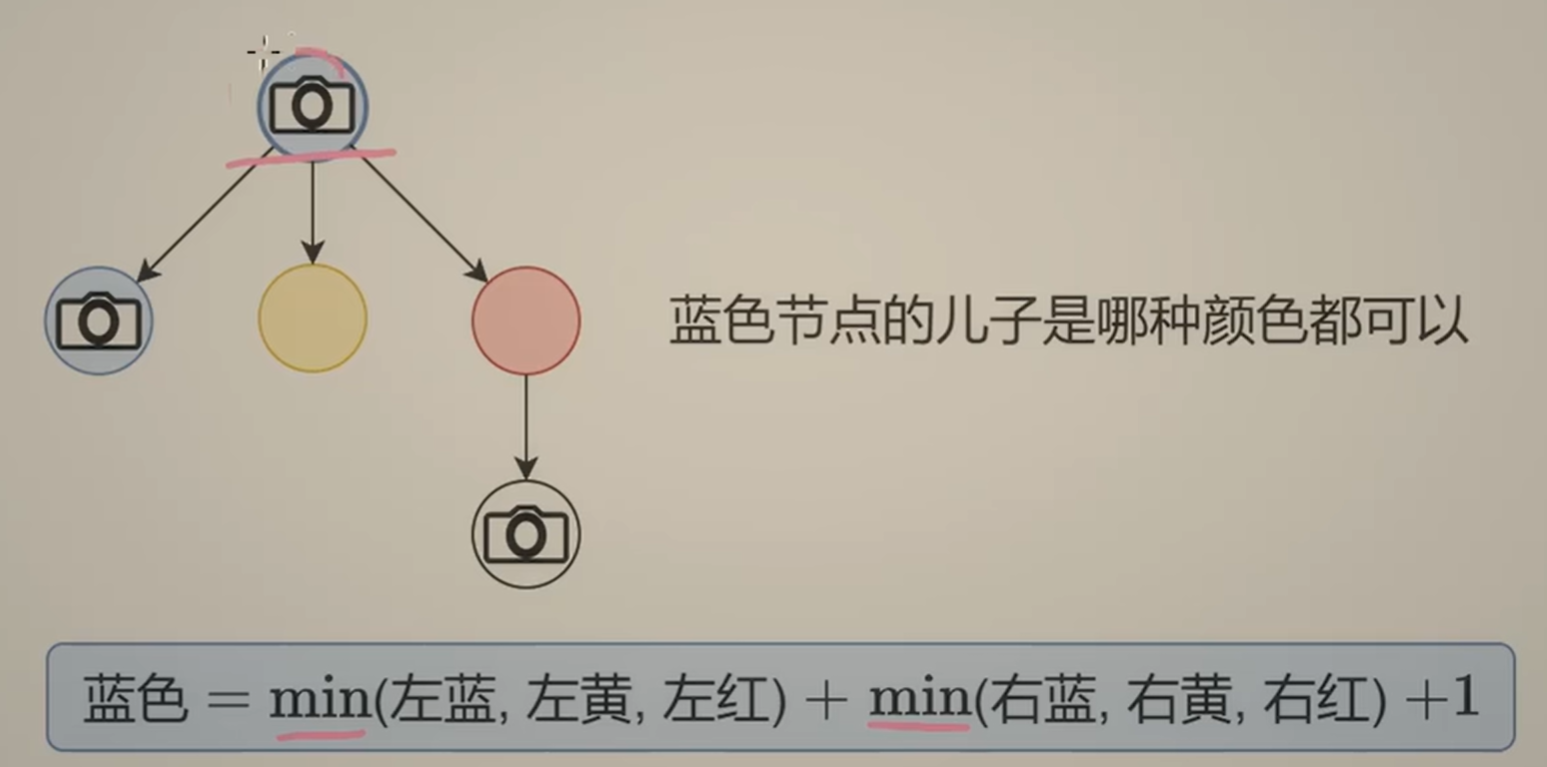
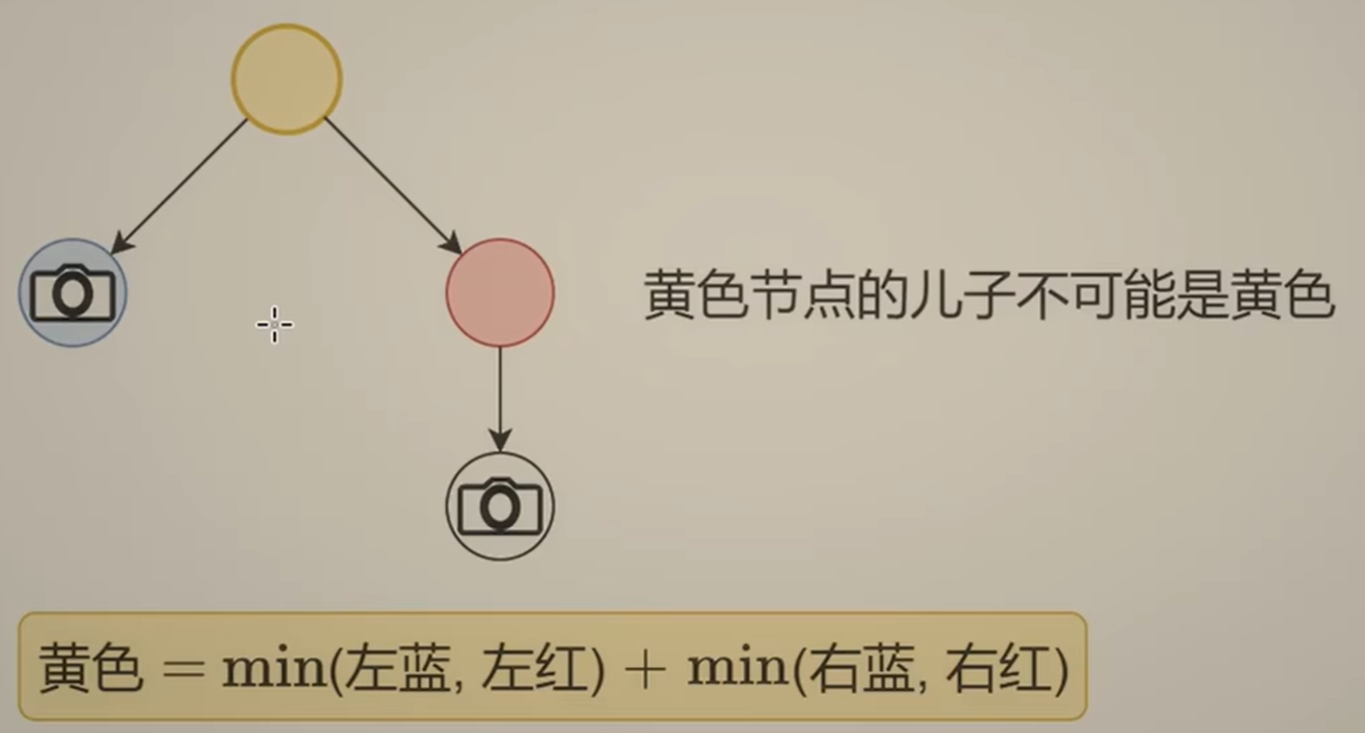
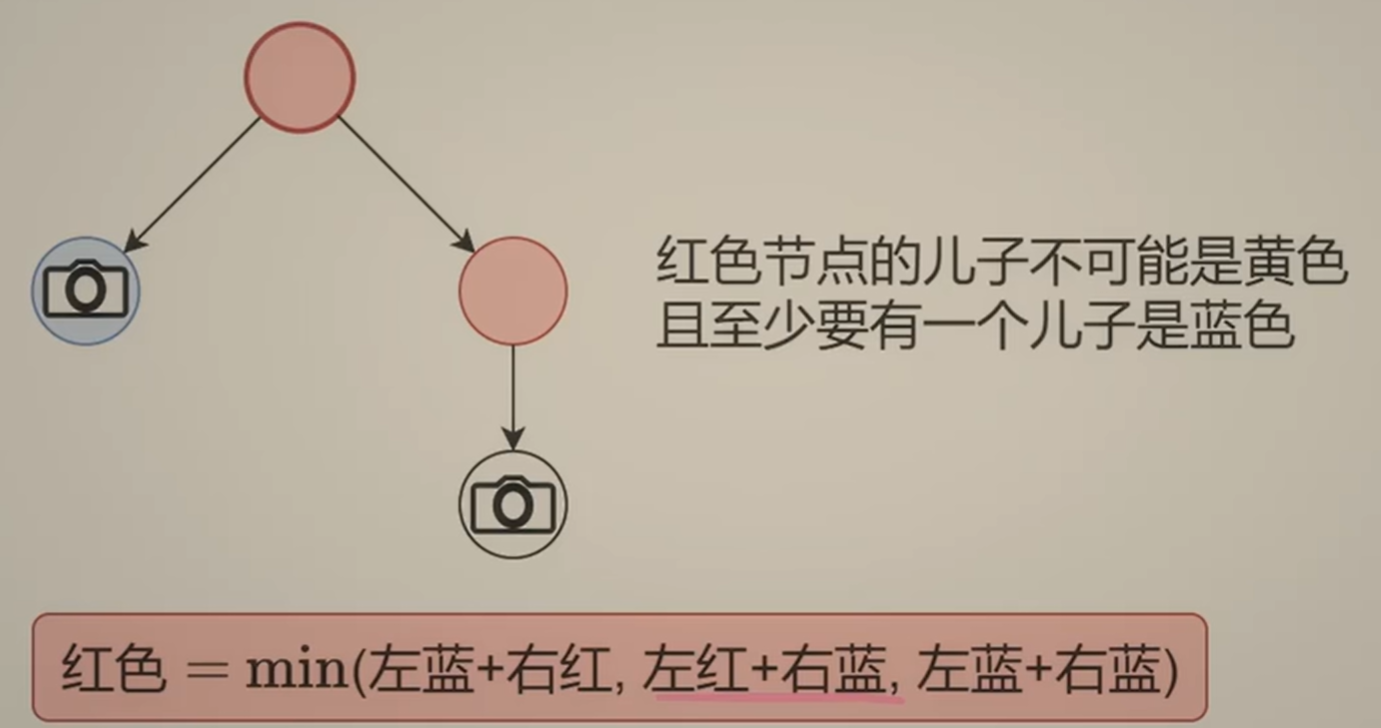
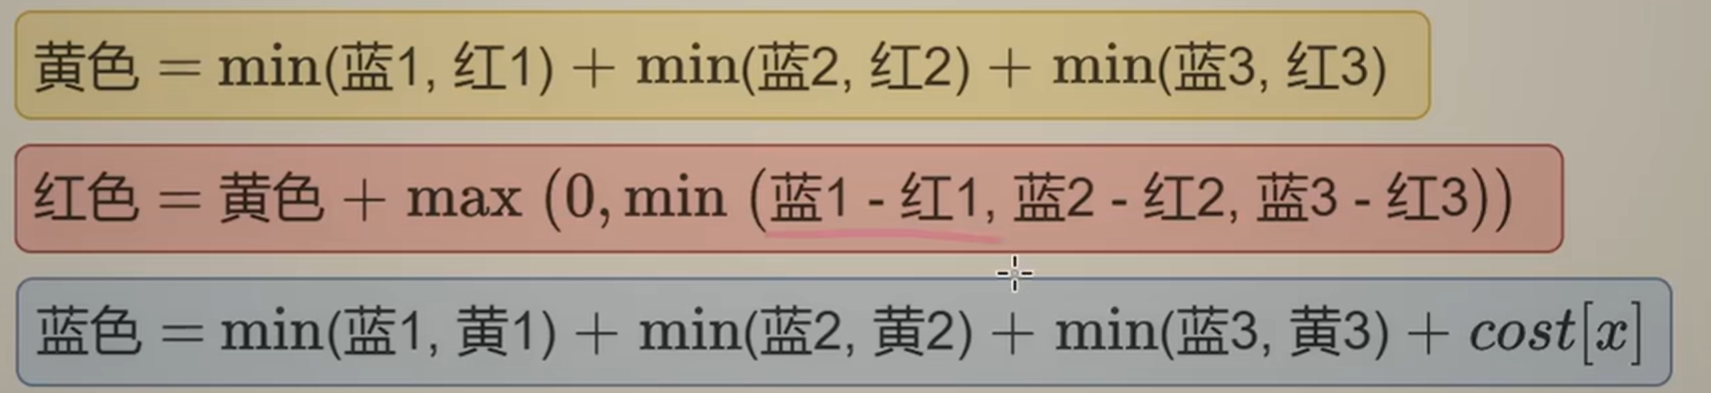

分析一下红色节点的处理逻辑，对于红色节点而言，它必须有一个子节点是蓝色节点，而对于黄色节点而言，它的子节点是由红色与蓝色构成的，因此可以在黄色的基础上构建答案，当黄色的结果中包含至少一个蓝色节点的时候，那么此时红色与黄色的值相同，而当黄色的子节点都是红色的时候，意味着对于任意一个子节点而言，蓝色的值比红色要大，因此我们可以选择将其中的一个红色节点进行替换，选择的依据是找到choose - by_fa最小的节点（但要大于0，否则黄色的结果中已经包含蓝色节点）进行变色，从而保证红色的结果在满足要求的情况下最小。同时从图中也可看出红色的代价值一定大于等于黄色，因此在节点为蓝色的时候不用去判断子节点为红色的情况。

**_二叉树版本的代码会处理到空节点，而一般树版本的代码只会处理到叶子节点。_**
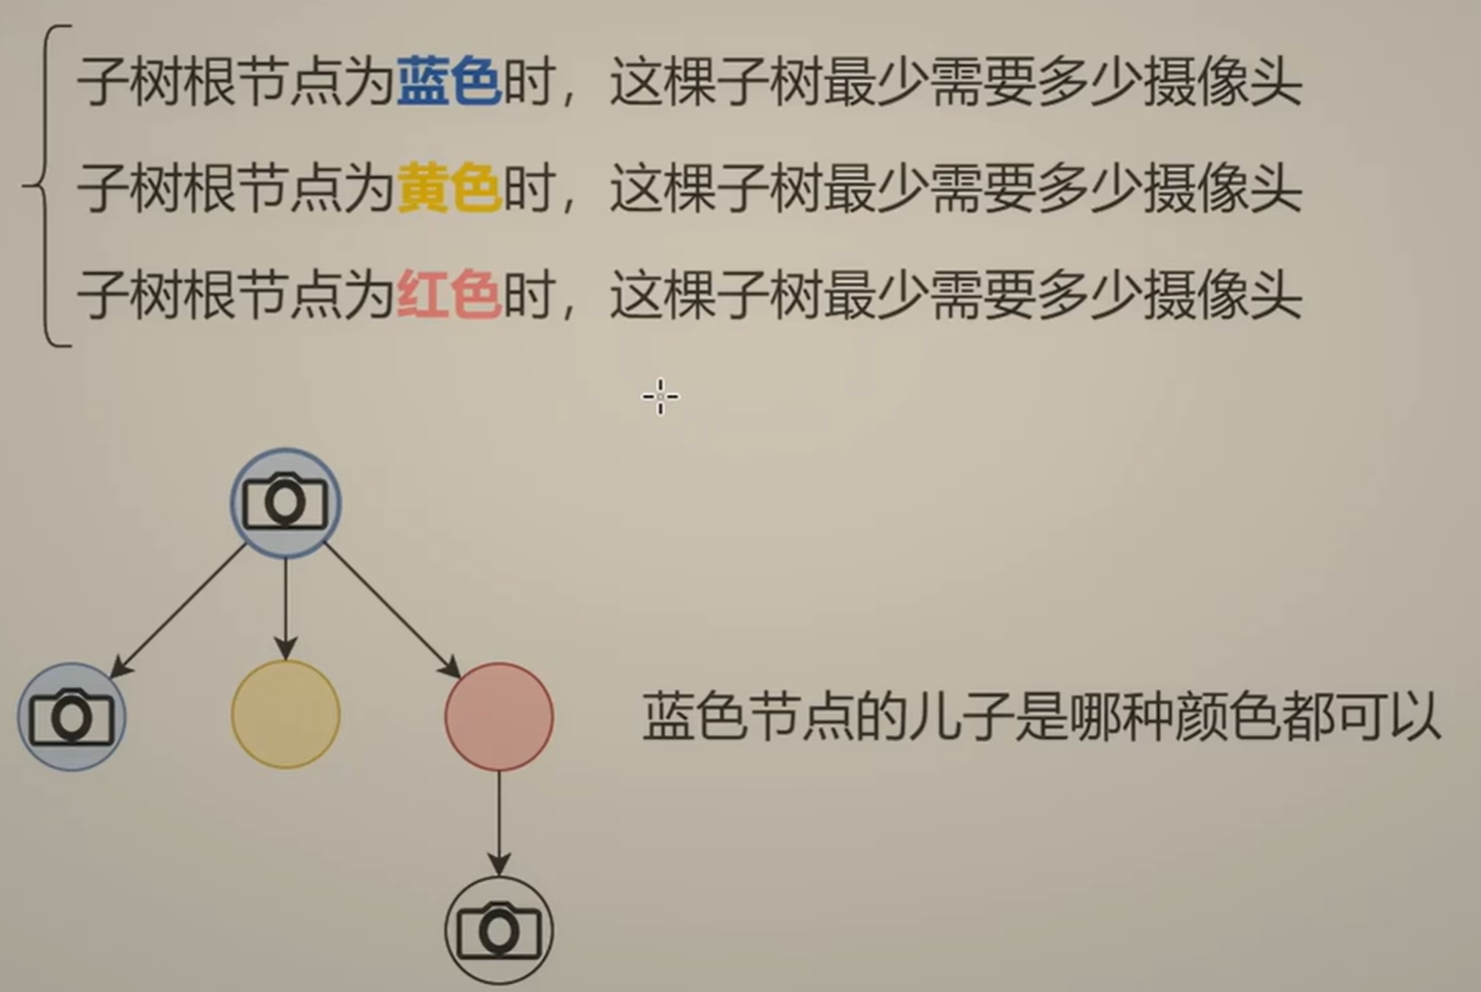

In [ ]:
#二叉树版本代码：
class Solution:
    def minCameraCover(self, root) -> int:
        def dfs(node):#dfs可以理解为当node节点作为根节点是覆盖所由节点的最小数目
            if not node:
                return inf,0,0#对于一个空节点而言，是不可能安装监控的，因此choose的情况下返回inf，虽然对于一个空节点而言，不可能有子节点，因此by_children的结果也不存在，但我们返回的值更注重对当前节点的处理，也就是说当前节点安不安装更加重要，因此被孩子监控的情况下，当前节点不安监控，返回0即可。
            l_choose,l_by_fa,l_by_children = dfs(node.left)
            r_choose,r_by_fa,r_by_children = dfs(node.right)
            choose = min(l_choose,l_by_fa) + min(r_choose,r_by_fa) + 1#把1改成cost[x]，变成监控所有节点的最小花费。
            by_fa = min(l_choose,l_by_children) + min(r_choose,r_by_children)#对于一个叶子节点而言，当被它的父亲监控的时候，by_fa = 0,但如果空节点的by_children设置为inf，那么by_fa的值为inf，显然是不对的，因此设置为0.
            by_children = by_fa + max(0,min(l_choose-l_by_children,r_choose-r_by_children))
            return choose,by_fa,by_children
        choose,_,by_children = dfs(root)
        return min(choose,by_children)

In [ ]:
#一般树版本代码：
class Solution:
    def minCameraCover(self,n,edges,cost) -> int:
        f = [[] for _ in range(n)]
        indegree = [0] * n
        for chi,par in edges:
            f[par].append(chi)
            indegree[chi] += 1

        def dfs(x):
            choose = cost[x]
            by_fa = 0
            min_num = inf
            for y in f[x]:
                y_choose,y_by_fa,y_by_children = dfs(y)
                choose += min(y_choose,y_by_fa)
                by_fa += min(y_choose,y_by_children)
                min_num = min(y_choose - y_by_children,min_num)
            by_children = by_fa + max(0,min_num)
            return choose,by_fa,by_children
        root = next(i for i in range(n) if indegree[i] == 0)
        choose,_,by_children = dfs(root)
        return max(choose,by_children)